# [LAB 07] 8. 이원분산분석
## #01. 준비작업
### 1. 패키지 참조

In [2]:
from hossam import load_data
from helpers import *
import numpy as np

# 데이터프레임 구성을 위한 라이브러리
from pandas import DataFrame

# 분산분석을 위한 라이브러리
from pingouin import anova, welch_anova
from statsmodels.formula.api import ols
import statsmodels.api as sm

# 사후 검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기
- 한 식물학자는 식물의 성장이 햇빛 노출과 관수 빈도에 의해 영향을 받는지 여부를 알고 싶어한다.
- 실험은 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록하였다.

In [3]:
origin = load_data('sunlight_watering_growth')
origin.head()

📚 식물의 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,water,sun,height
0,daily,low,4.900
1,daily,low,7.900
2,daily,low,3.900
3,daily,low,5.100
4,daily,low,5.200


## #02. 데이터 분포 시각화
### 1. 관수 빈도에 따른 햇빛 노출량별 따른 식물 높이 비교(1/2)
- 필요한 변수를 정의하고 데이터를 필터링 한다.

In [4]:
# 필요한 변수 정의
field = 'height'           # 연속형 컬럼명
group_field = 'water'      # 명목형 컬럼명 1 (~에 따른)
hue_field = 'sun'          # 명목형 컬럼명 2 (~별)

# 그룹별 값의 종류 확인
group_values = origin[group_field].unique()
print(f'그룹별 값의 종류: {group_values}')

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]
data.head()

그룹별 값의 종류: <ArrowStringArray>
['daily', 'weekly']
Length: 2, dtype: str


,height,water,sun
0,4.900,daily,low
1,7.900,daily,low
2,3.900,daily,low
3,5.100,daily,low
4,5.200,daily,low


### 2. 관수빈도에 따른 햇빛 노출량 별 따른 식물 높이 비교(2/2)
- 반복문을 수행하면서 데이터를 시각화 한다.

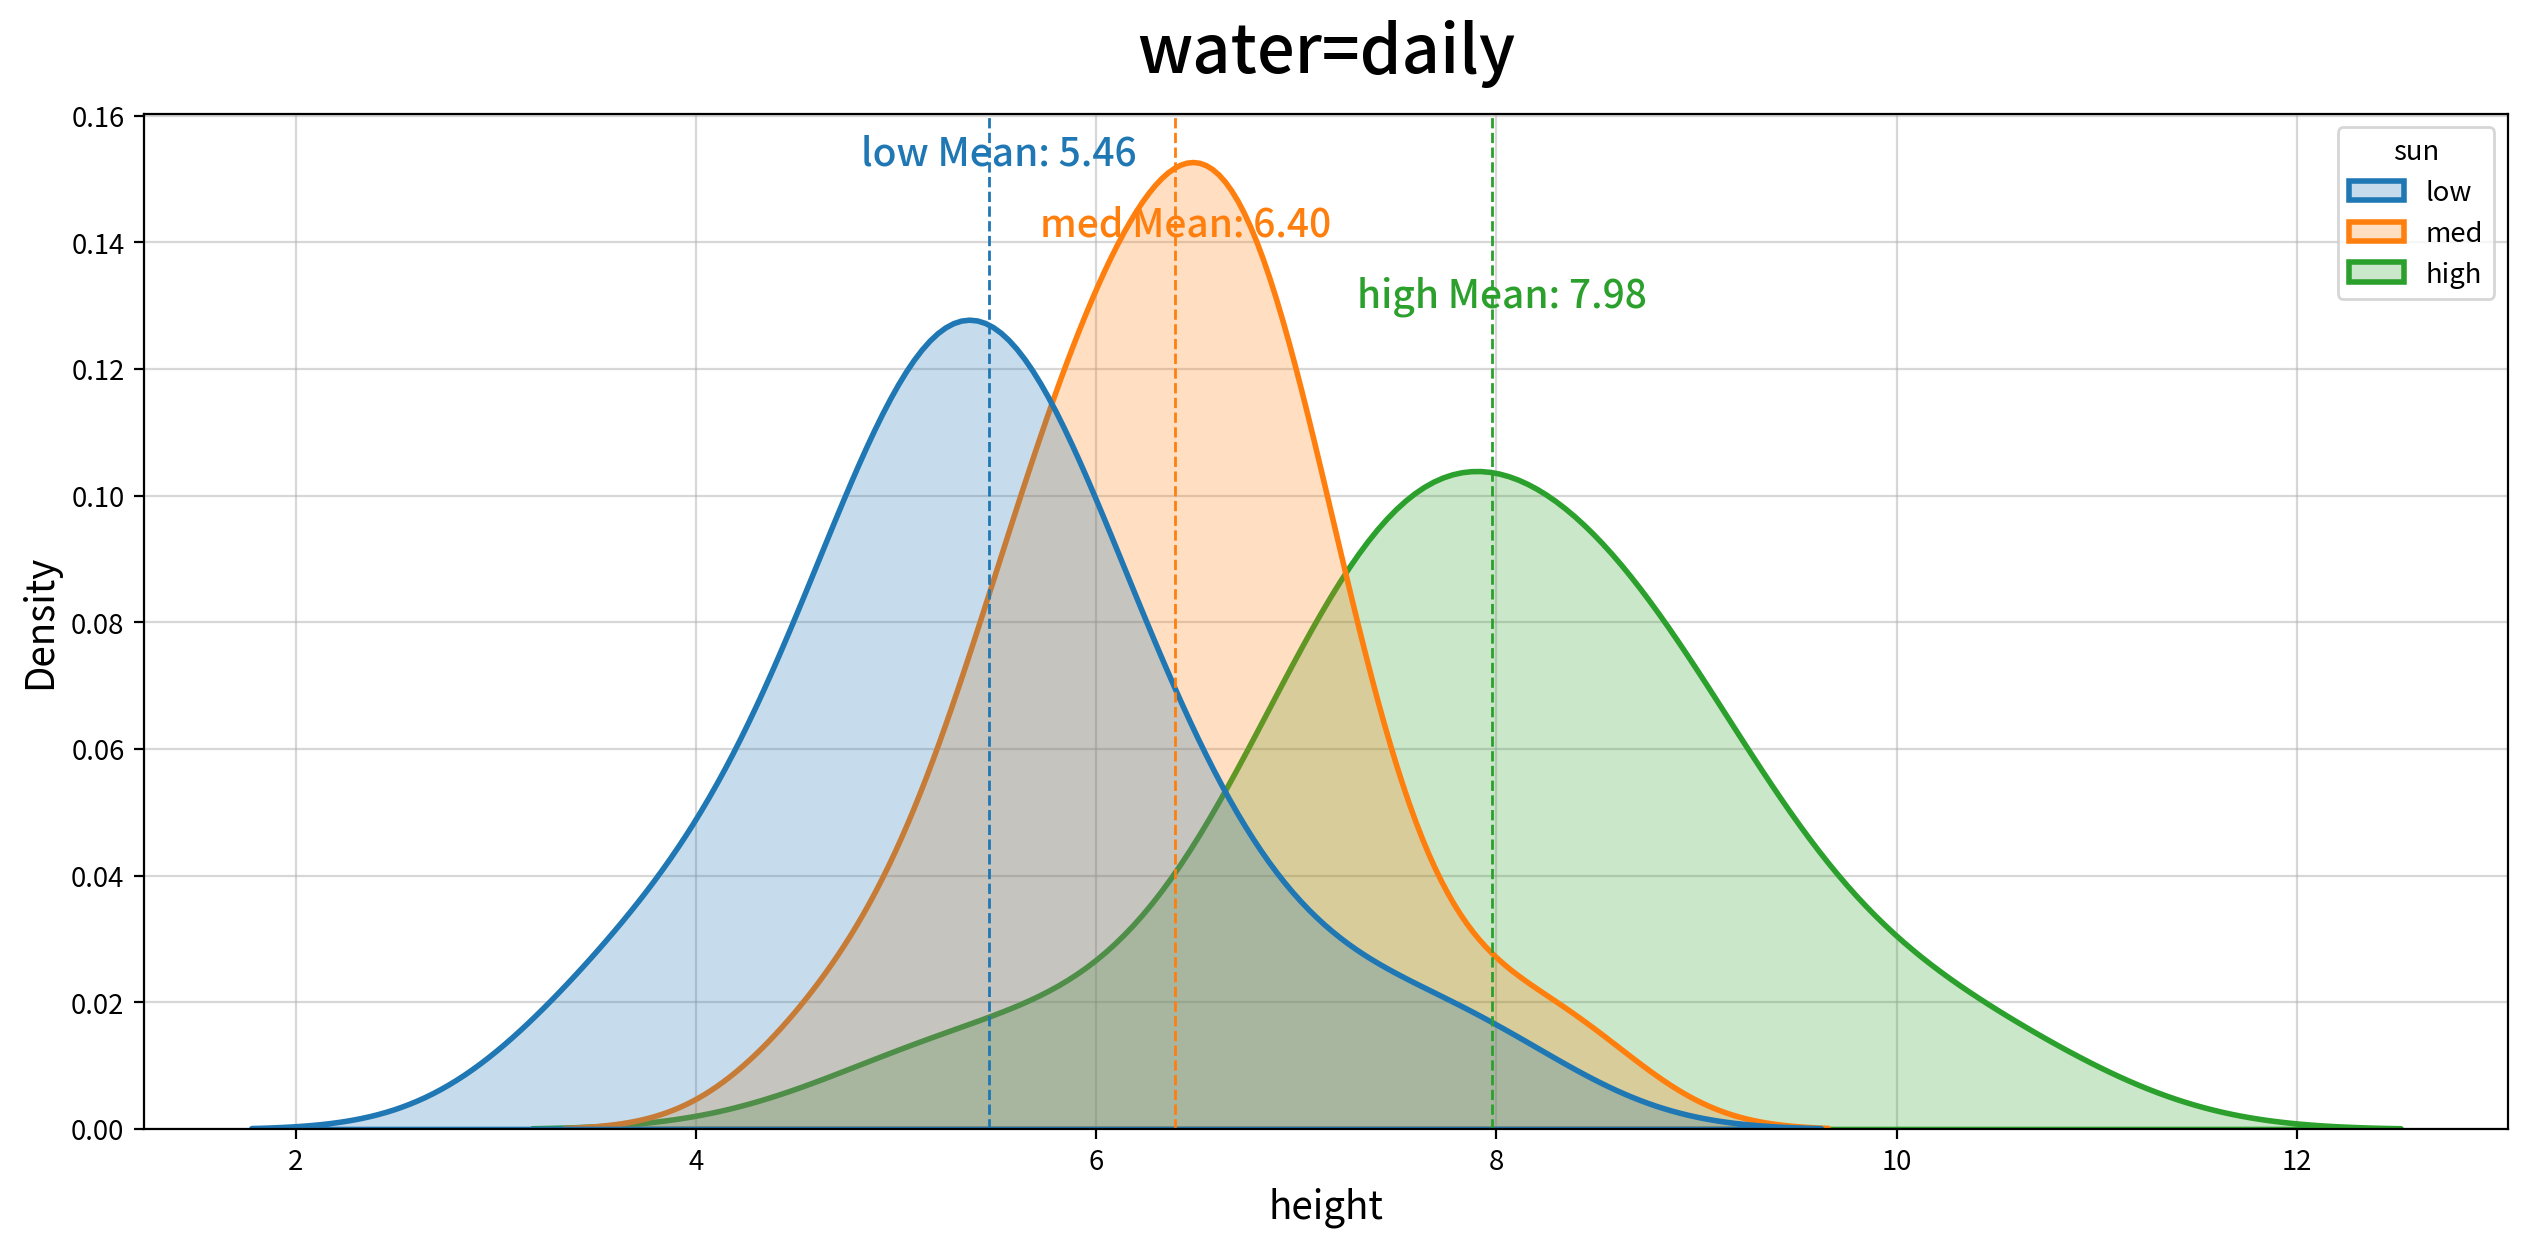

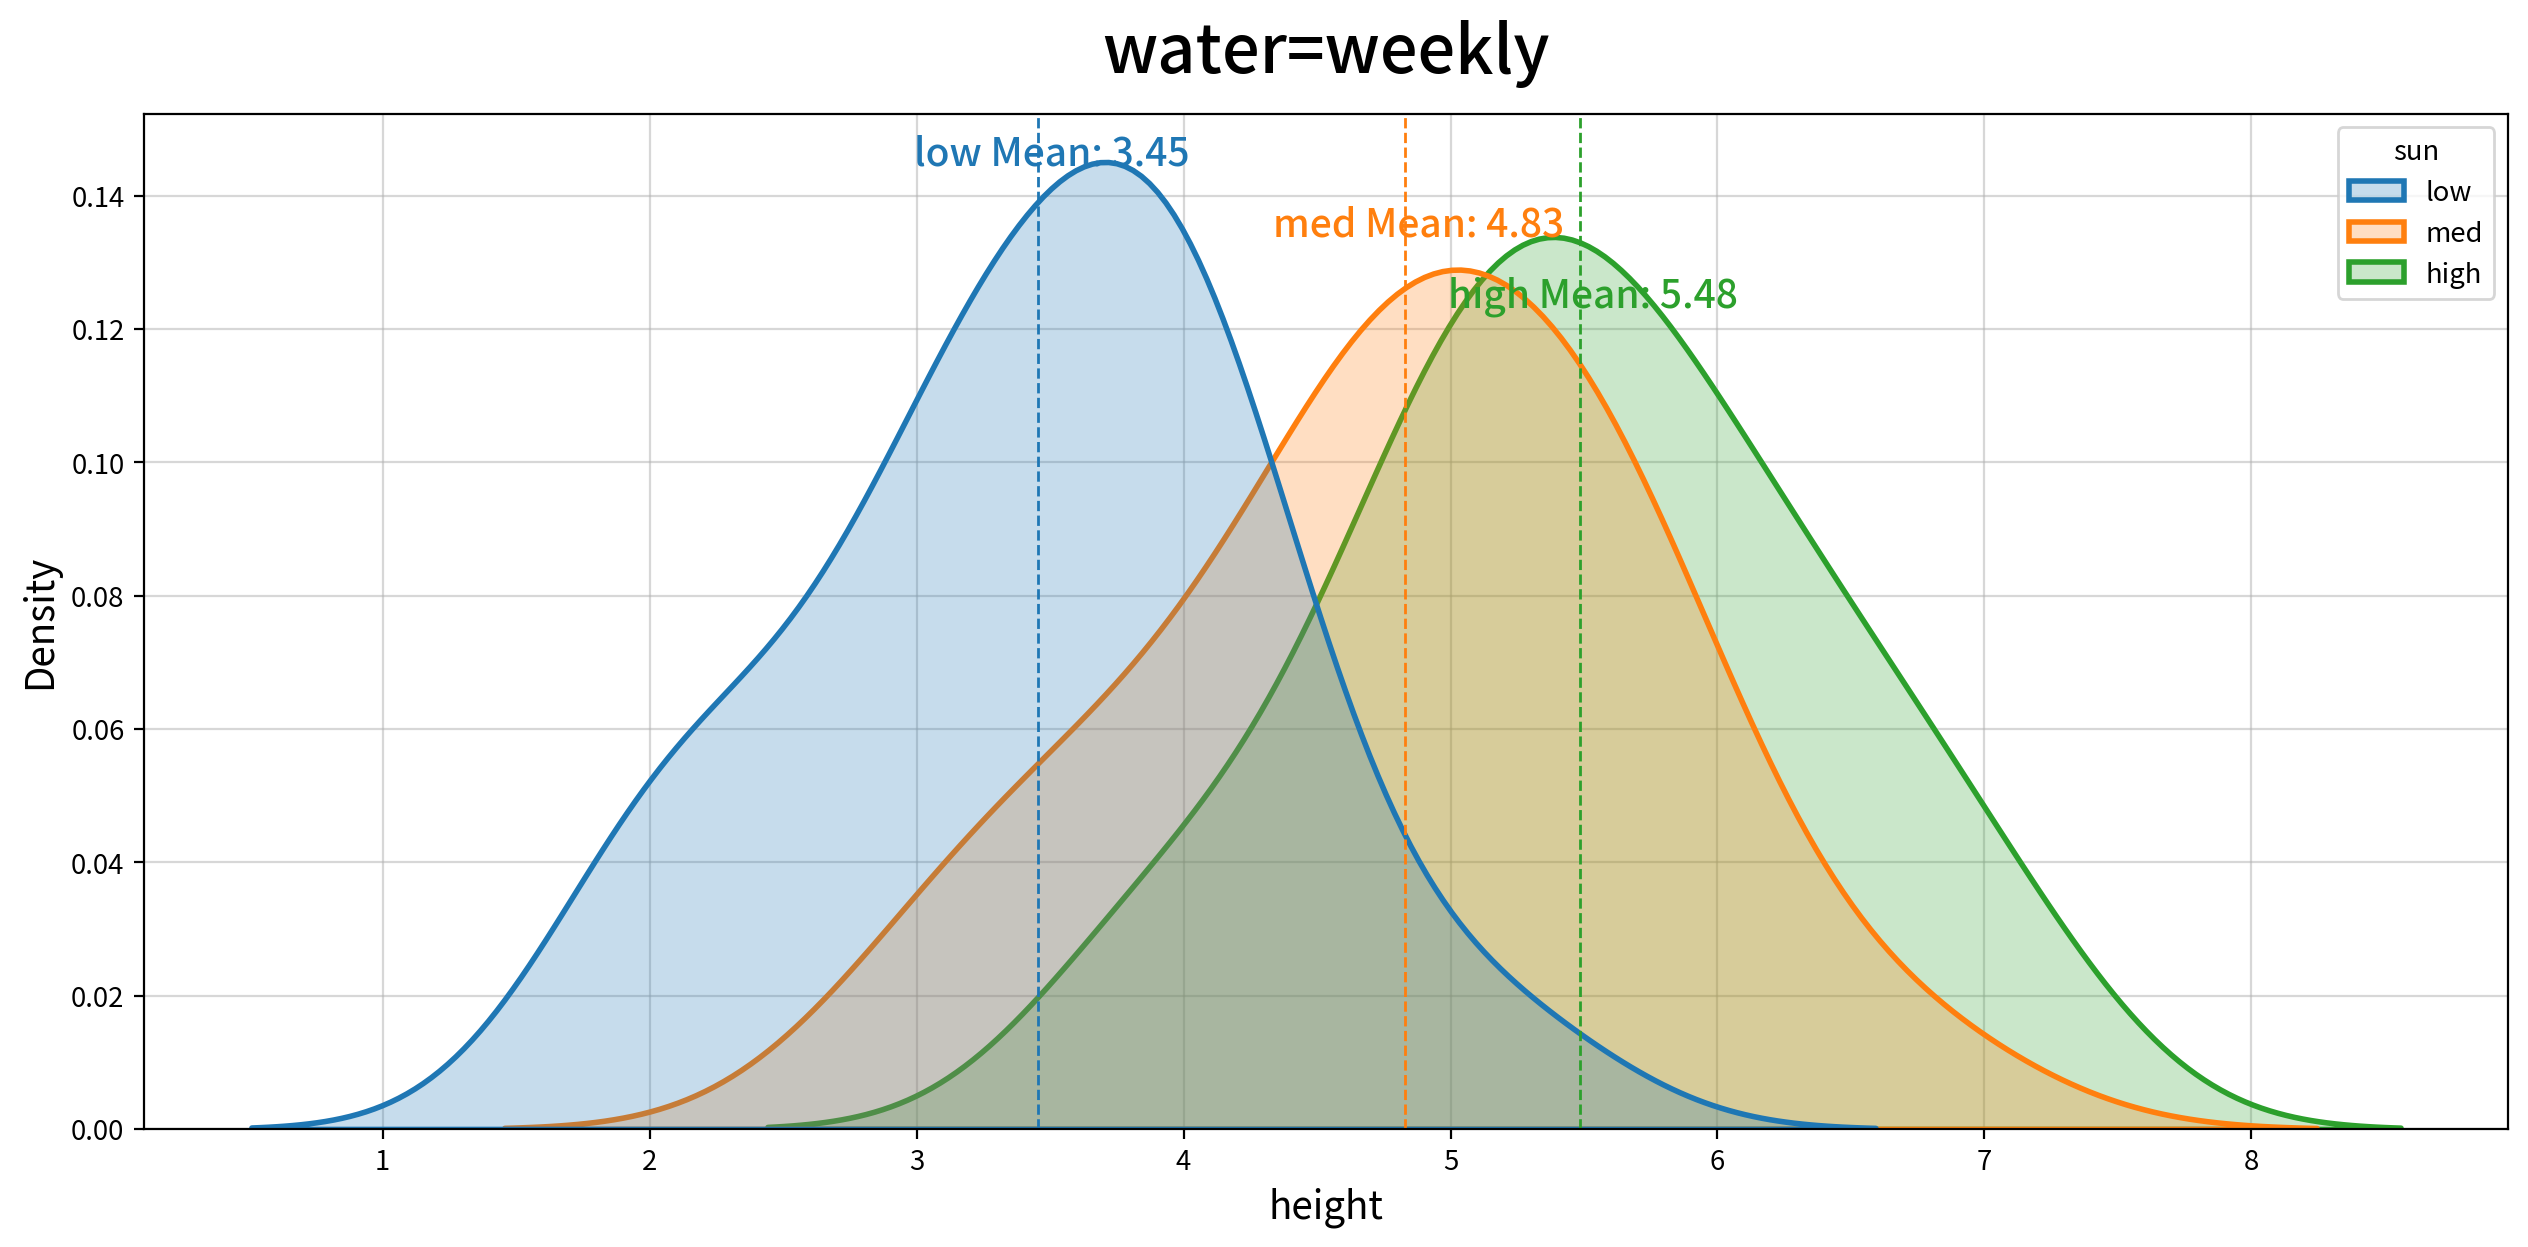

In [5]:
for i, v, in enumerate(group_values):
    temp = data[data[group_field] == v]

    my_plot.kdeplot(data=temp, x=field, hue=hue_field, fill=True, meanline=True, title=f'{group_field}={v}')

### 3. 햇빛 노출량에 따른 관수빈도별 식물 높이 비교

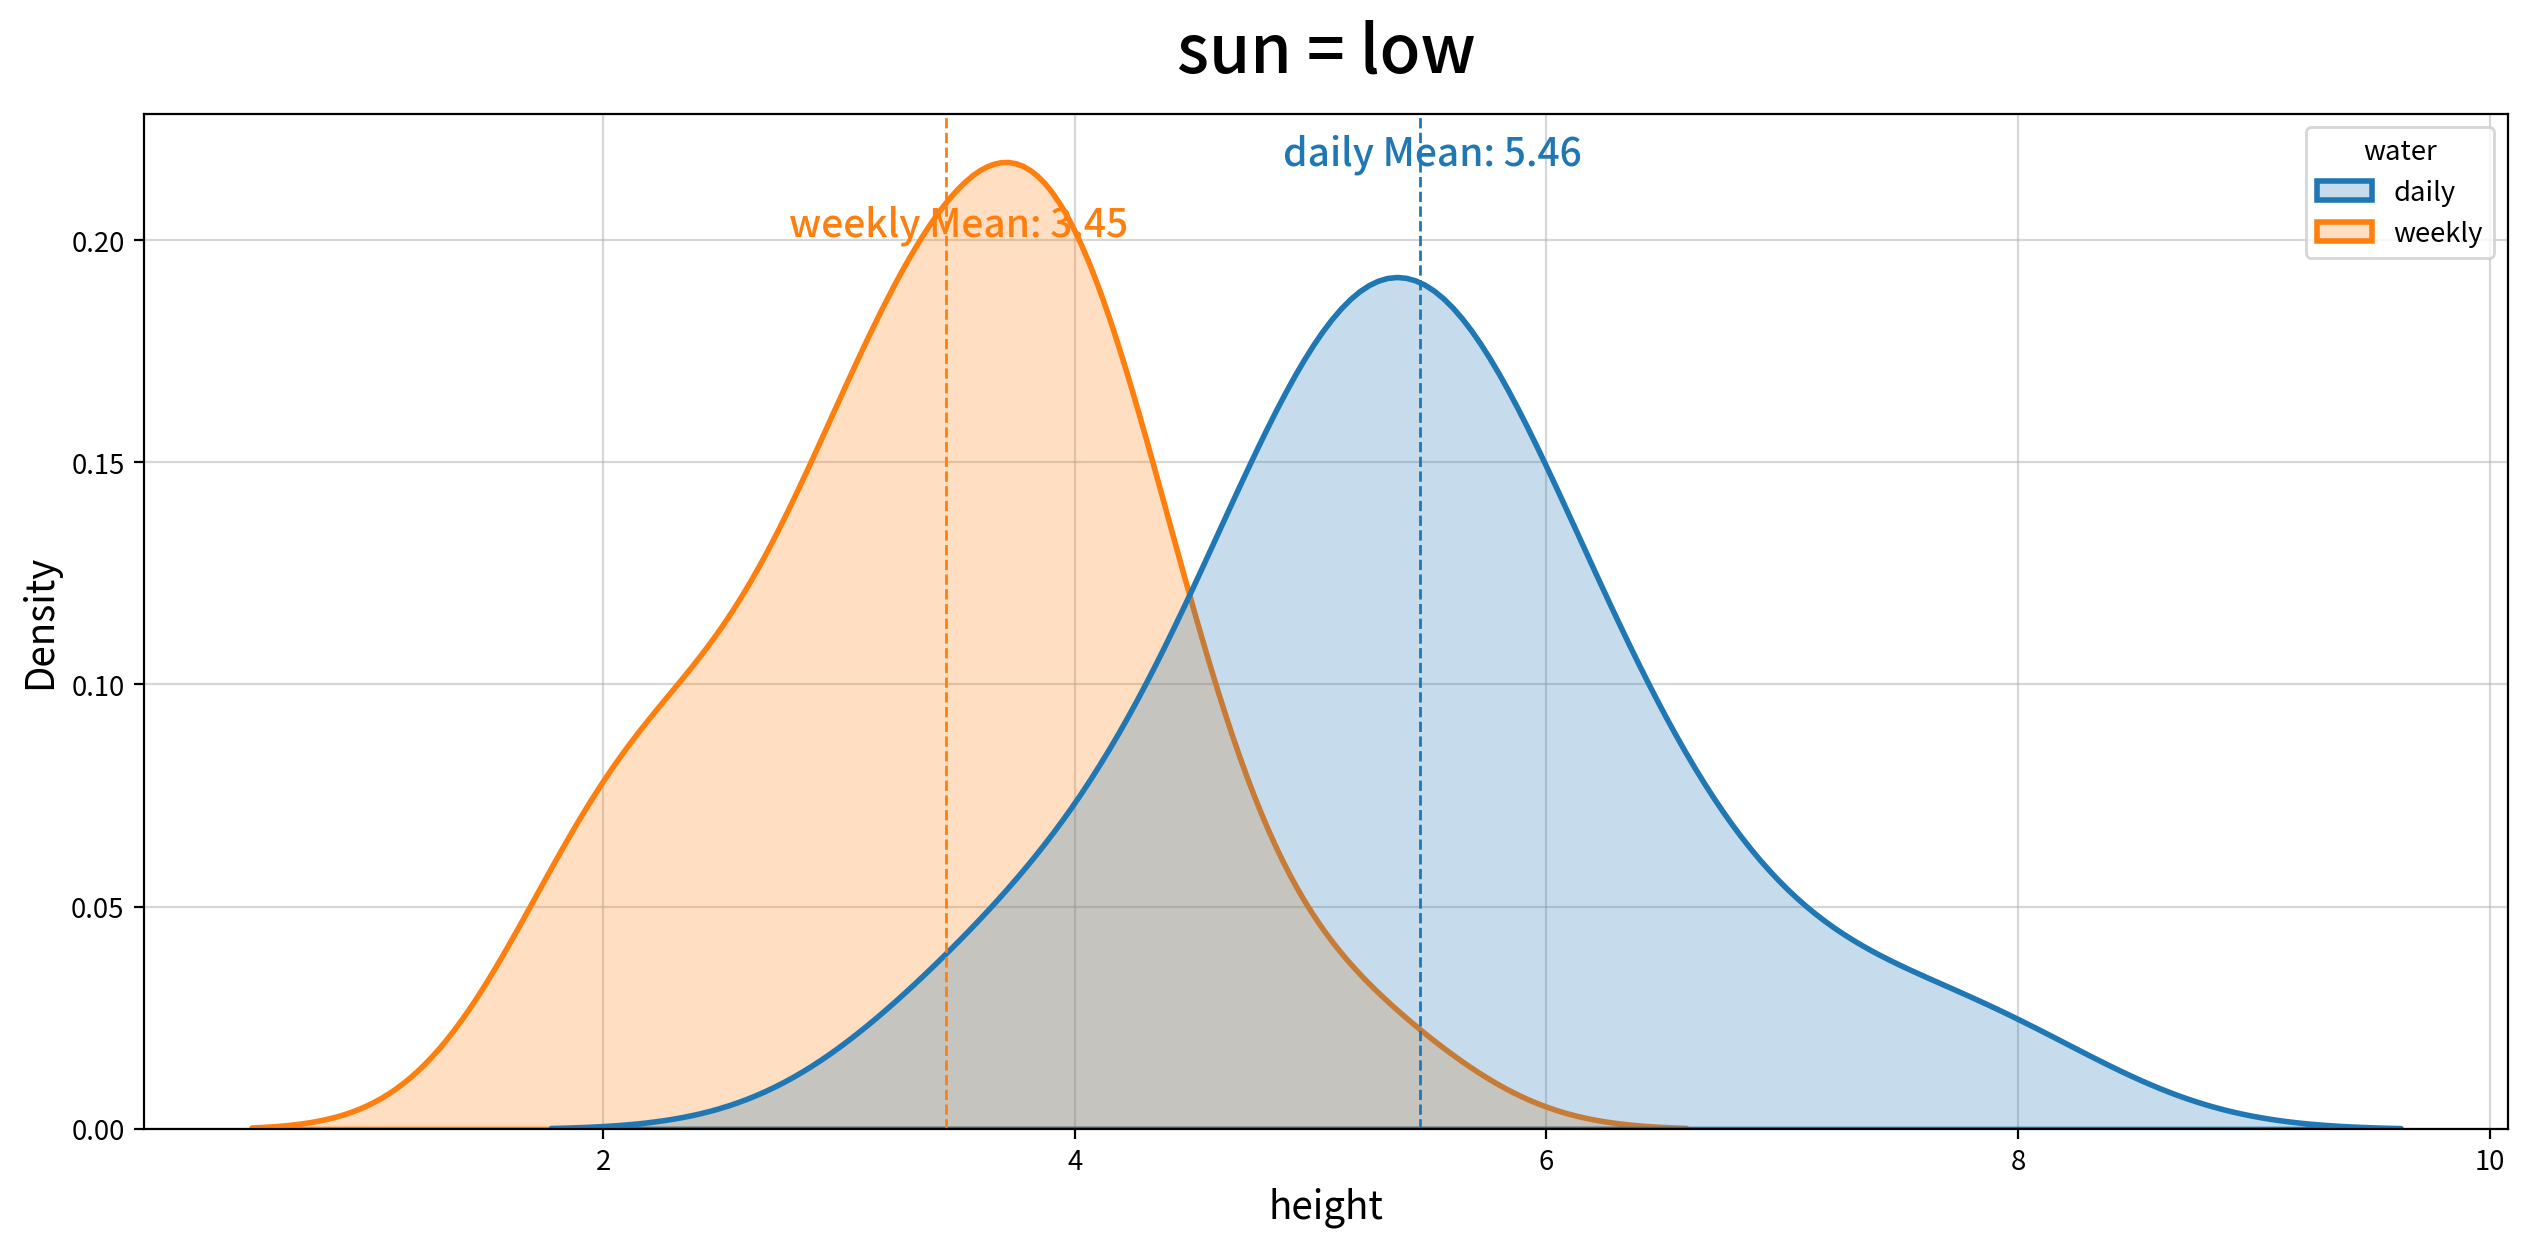

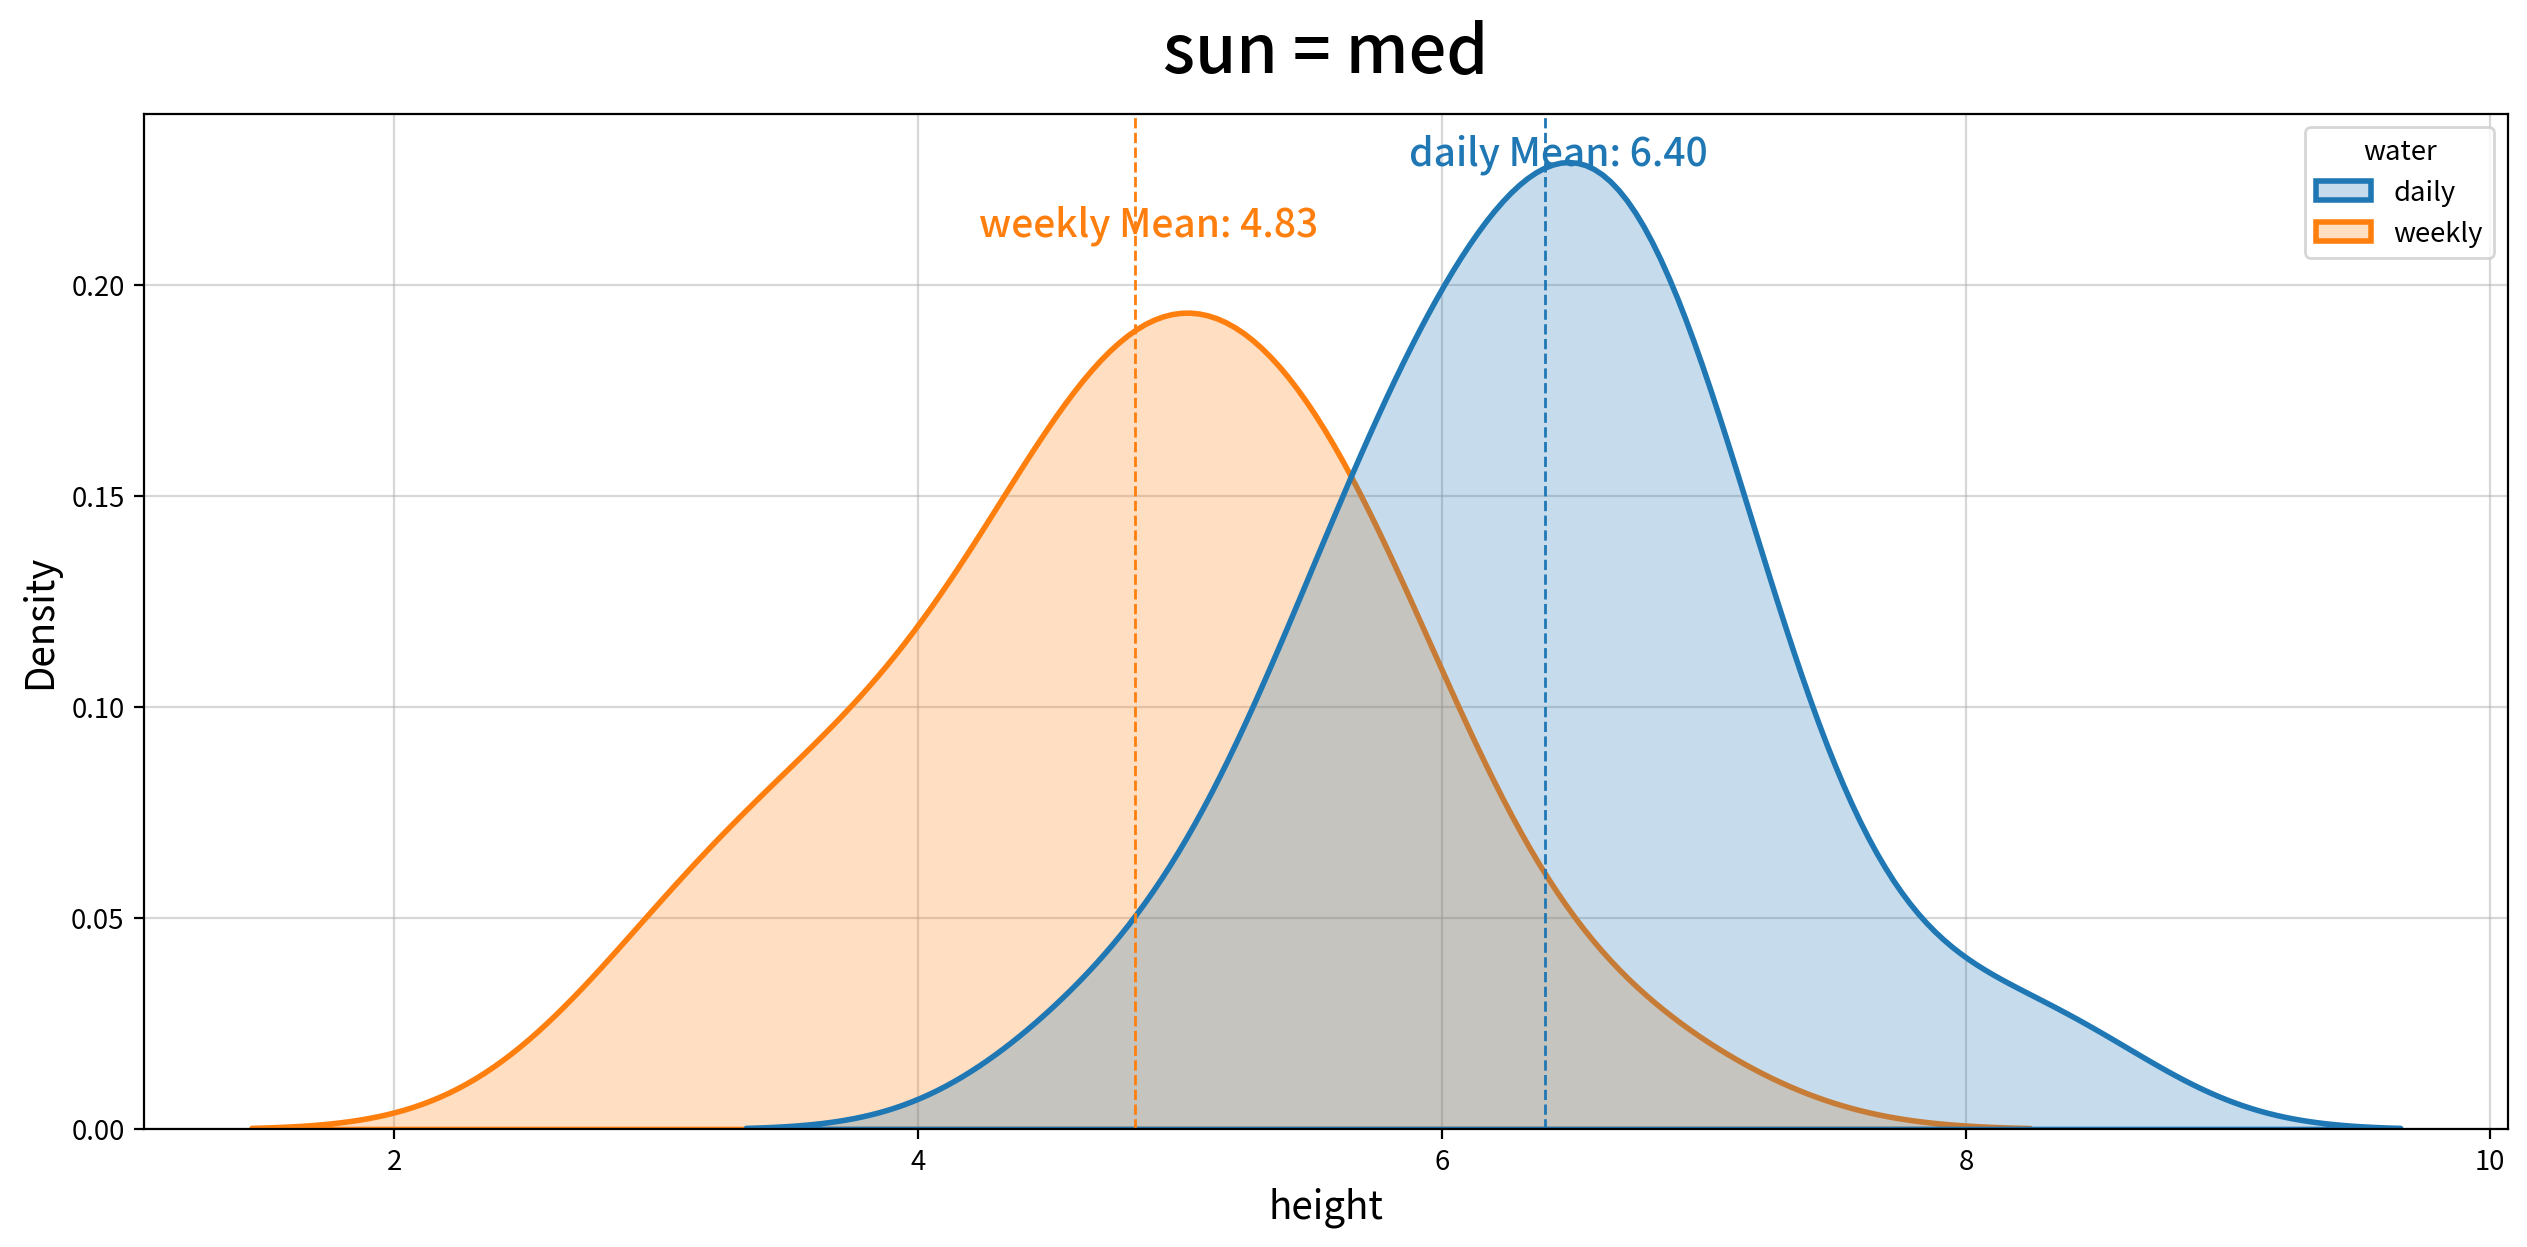

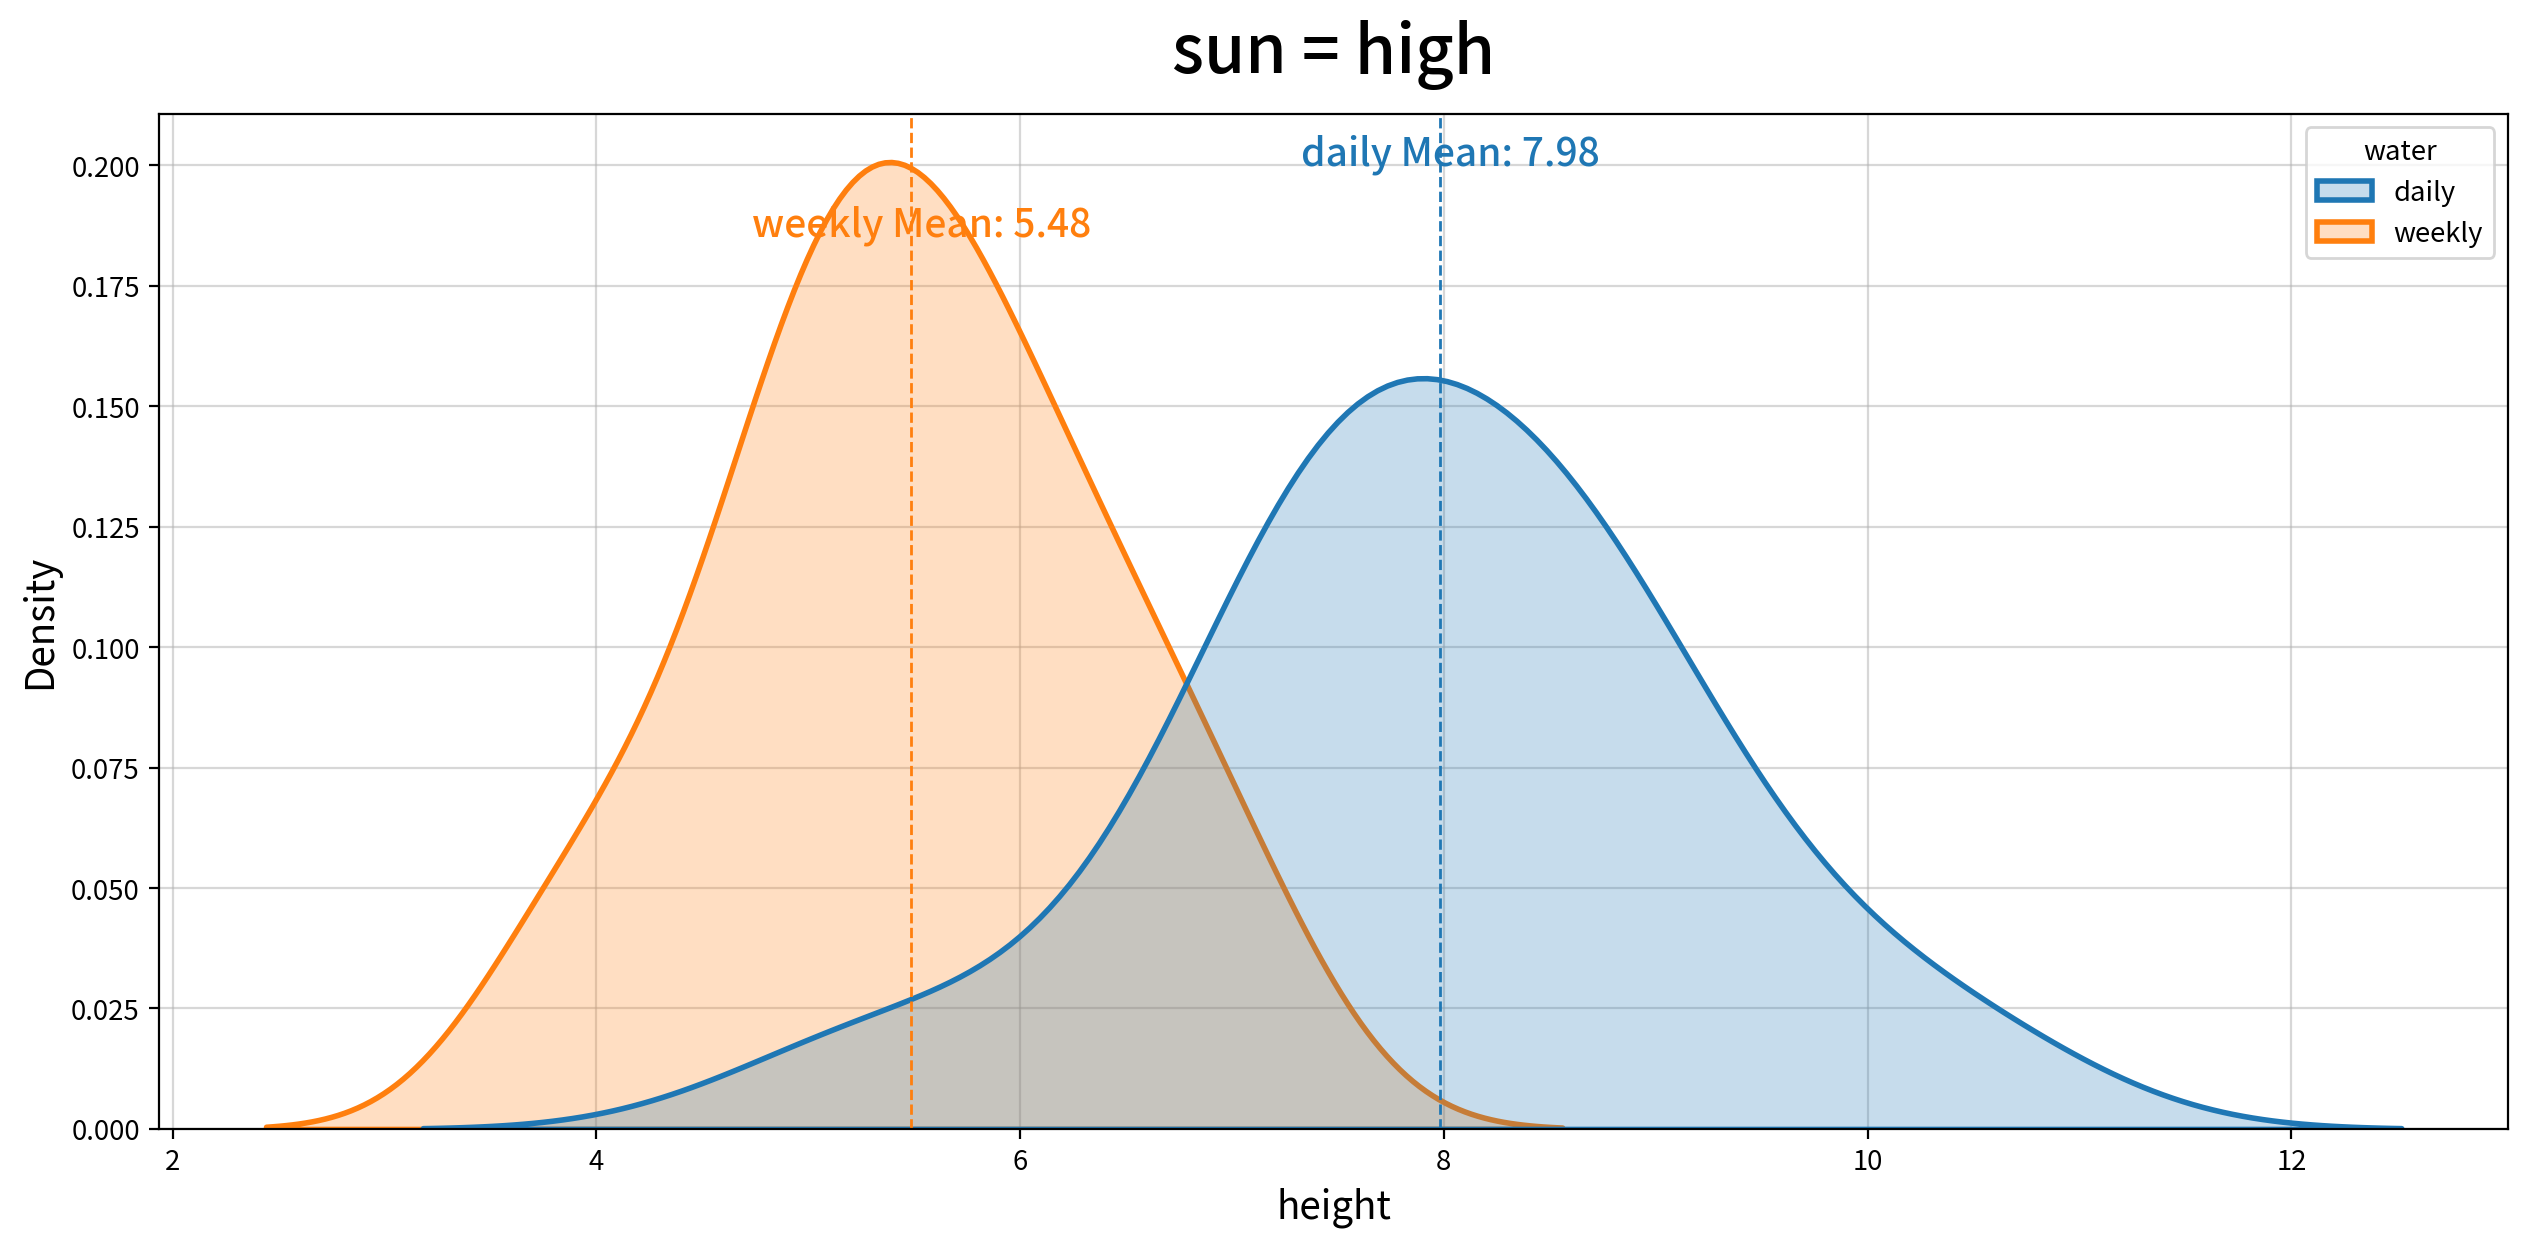

In [6]:
# 필요한 변수 정의
field = 'height'      # 연속형 컬럼명
group_field = 'sun'   # 명목형 컬럼명 1 (~~에 따른)
hue_field = 'water'   # 명목형 컬럼명 2 (~~별)

# 그룹별 값의 종류 확인
group_values = origin[group_field].unique()

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]

# 시각화
for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]
    my_plot.kdeplot(data=temp, x=field, hue=hue_field, fill=True, meanline=True, title=f'{group_field} = {v}')

### 4. 분산분석의 가정 확인
- 이원분산분석에서는 등분산 가정이 충족되지 않을 경우 적절한 대안이 없다.
- 이 경우 선형모형으로 전환해야 한다.

In [7]:
data = origin.copy()
xname = ['water', 'sun']   # 명목형 변수의 이름
yname = 'height'           # 연속형 변수의 이름

# 두 명목형 변수의 모든 조합별로 연속형 변수 값을 별도의 컬럼으로 분리한다.
groups = {}
for i in data[xname[0]].unique():
    for j in data[xname[1]].unique():
        # 명목형 변수의 조합에 맞는 데이터를 추출한다.
        filered_date = data[(data[xname[0]] == i) & (data[xname[1]] == j)][yname]
        groups["{0}, {1}".format(i,j)] = filered_date.reset_index(drop=True)

# 조합별 표본 크기가 다를 수 있으므로 DataFrame으로 결합하면 짧은 쪽은 NaN으로 채워진다.
# test_assumptions는 내부적으로 결측치를 제거한 뒤 검정하므로 문제되지 않는다.
group_df = DataFrame(groups)
group_df

,"daily, low","daily, med","daily, high","weekly, low","weekly, med","weekly, high"
0,4.900,5.600,8.600,3.900,4.800,5.200
1,7.900,6.500,8.800,3.300,3.600,4.700
2,3.900,6.500,9.200,4.300,5.700,6.900
3,5.100,6.000,7.100,3.300,4.100,5.100
4,5.200,7.100,8.600,4.500,4.600,7.100
5,6.500,6.800,5.200,1.900,4.800,5.700
6,5.800,4.700,6.900,3.700,3.900,4.600
7,5.800,6.700,7.500,4.100,4.700,3.900
8,5.600,5.500,9.800,3.000,5.400,6.400
9,4.600,5.900,7.500,2.600,5.600,5.500


In [8]:
# 정규성(normaltest)과 등분산성(Bartlett/Levene) 가정을 일괄 검정한다.
report_df = my_stats.test_assumptions(group_df)
report_df

,test,statistic,p-value,result
field,,,,
"daily, low",normaltest,1.462,0.482,True
"daily, med",normaltest,0.867,0.648,True
"daily, high",normaltest,0.802,0.670,True
"weekly, low",normaltest,0.074,0.964,True
"weekly, med",normaltest,0.161,0.923,True
"weekly, high",normaltest,0.053,0.974,True
Bartlett,equal_var,4.488,0.481,True


In [9]:
# 등분산성 충족 여부 (이후 사후검정 방법 선택에 사용)
equal_var = bool(report_df.loc[report_df['test'] == 'equal_var', 'result'].iloc[0])
equal_var

True

## #03. 이원분산분석(Two-way ANOVA) 수행
- 앞서 확인한 등분산성 가정(equal_var)에 따라 분석 방법을 분기한다.
- 등분산성 충족 시 : 일반적인 이원분산분석(pingouin.anova)을 수행한다.
- 등분산성 미충족 시 : 이원분산분석에는 Welch같은 적절한 대안이 없으므로, 등분산을 가정하지 않는 선형모형(statsmodels OLS+HC3 강건표준오차) 기반의 Type-2 ANOVA로 전환한다.
- 검정대상은 두개의 주효과(water, sun)와 하나의 상호작용효과(water*sun)이다.
    - H0 : 해당 효과(요인 평균차 또는 상호작용)가 존재하지 않는다.
    - H1 : 해당 효과가 존재한다.

In [10]:
# 분석 변수 정의
data = origin.copy()
xname = ['water', 'sun']  # 명목형(독립) 변수
yname = 'height'          # 연속형(종속) 변수

# 등분산성 가정(equal_var) 충족 여부에 따라 분석 방법 분기
if equal_var:
    # [등분산 충족] 일반 이원분산분석
    aov = anova(data=data, dv=yname, between=xname).round(4)
    aov.insert(0, 'test', 'two-way ANOVA')

    # p값 컬럼명은 pingouin 버전에 따라 다를 수 있어 유연하게 선택
    pcol = 'p-unc' if 'p-unc' in aov.columns else 'p_unc'

    # 효과크기(np2, partial eta-squared) 해석 (>=0.14 큼 / >=0.06 중간 / >=0.01 작음)
    conditions = [aov['np2'] >=0.14 , aov['np2'] >=0.06, aov['np2'] >=0.01]
    aov['effect_size'] = np.select(conditions, ['Large', 'Medium', 'Small'], default='Negligible')

else:
    # [등분산 미충족] 등분산을 가정하지 않는 선형모형(HC3) 기반 Type-2 ANOVA
    model = ols(f'{yname} ~ C{xname[0]} * C{xname[1]}', data=data.fit(cov_type='HC3'))
    aov = sm.stats.anova_lm(model, typ=2, robust='hc3').round(4)
    aov.insert(0, 'test', 'OLS (HC3) TYPE-II ANOVA')
    pcol = 'PR(>F)'

# 유의성 판정 컬럼 추가(p < 0.05이면 효과 존재)
aov['significant'] = aov[pcol] < 0.05
aov

,test,Source,SS,DF,MS,F,p_unc,np2,effect_size,significant
0,two-way ANOVA,water,122.816,1,122.816,130.529,0.000,0.534,Large,True
1,two-way ANOVA,sun,103.292,2,51.646,54.889,0.000,0.491,Large,True
2,two-way ANOVA,water * sun,4.327,2,2.164,2.300,0.105,0.039,Small,False
3,two-way ANOVA,Residual,107.264,114,0.941,NaN,NaN,NaN,Negligible,False


- 이원분산분석 결과에 대한 인사이트
    - 등분산성 가정이 충족되어 일반 이원분산분석으로 분석하였다.
    - 관수 빈도(water) 주효과는 유의하다 (p < 0.001). 효과크기(np2=0.534)가 매우 커서, 매일 물을 준 식물(daily)이 주 1회 물을 준 식물(weekly)보다 분명하게 더 크게 자랐다.
    - 햇빛 노출(sun) 주효과도 유의하다 (p < 0.001, np2=0.491). 햇빛 노출량이 많을수록(high > med > low) 식물이 더 크게 자랐다.
    - 상호작용효과(water × sun)는 유의하지 않다 (p = 0.105 > 0.05). 효과크기 라벨은 Small(np2=0.039)이지만 통계적으로 유의하지 않으므로, 관수 빈도가 미치는 효과의 크기가 햇빛 노출 수준에 따라 크게 달라지지 않는다고 본다. 즉 두 요인은 서로 독립적·가산적(additive) 으로 식물 성장에 기여한다고 해석할 수 있다.
    - 결론: 식물 성장(height)은 관수 빈도와 햇빛 노출 각각에 의해 강하게 영향을 받으며, 두 요인의 결합 방식에 따른 시너지/상쇄(상호작용)는 통계적으로 확인되지 않았다.

## #04. 사후검정(Post-hoc)
- 분산분석은 "집단간 차이가 존재하는가"만 알려줄 뿐 어떤 집단끼리 차이가 나는지는 알려주지 않는다.
- 이를 확인하기 위해 두 명목형 변수를 결합한 조합(셀) 단위 (water, sun)의 6개 집단에 대해 모든 쌍을 비교한다.
- 등분산성 가성에 따라 사후검정 방법을 분기한다.
    - 등분산 충족 시 : Tukey HSD
    - 등분산 미충족 시 : Games-Howell

In [11]:
# 두 명목형 변수를 결합하여 조합(셀) 단위의 집단 컬럼 생성 → 6개 집단의 모든 쌍 비교
ph = origin.copy()
ph['group'] = ph[xname[0]].astype(str) + ', ' + ph[xname[1]].astype(str)

# 등분산성 가정에 따라 사후검정 방법 분기
if equal_var:
    posthoc_name = 'Tukey HSD'
    posthoc = pairwise_tukey(data=ph, dv=yname, between='group')
    # pingouin 버전에 따라 p값 컬럼명이 다를 수 있어 유연하게 선택
    ppcol = 'p-tukey' if 'p-tukey' in posthoc.columns else 'p_tukey'

else:
    posthoc_name = 'Games-Howell'
    posthoc = pairwise_gameshowell(data=ph, dv=yname, between='group')
    ppcol = 'pval'

# 어떤 사후검정을 사용했는지 식별용 컬럼 추가
posthoc.insert(0, 'test', posthoc_name)

# 유의성 판정 (p < 0.05 이면 두 집단 간 차이 존재)
posthoc['significant'] = posthoc[ppcol] < 0.05

# 효과크기(|Hedges' g|) 해석 (≥0.8 큼 / ≥0.5 중간 / ≥0.2 작음)
abs_hedges = posthoc['hedges'].abs()
conditions = [abs_hedges >= 0.8, abs_hedges >= 0.5, abs_hedges >= 0.2]
posthoc['effect_size'] = np.select(conditions, ['Large', 'Medium', 'Small'], 
default='Negligible')

posthoc.round(4)

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,"daily, high","daily, low",7.980,5.465,2.515,0.307,8.199,0.000,2.165,True,Large
1,Tukey HSD,"daily, high","daily, med",7.980,6.395,1.585,0.307,5.167,0.000,1.488,True,Large
2,Tukey HSD,"daily, high","weekly, high",7.980,5.485,2.495,0.307,8.134,0.000,2.288,True,Large
3,Tukey HSD,"daily, high","weekly, low",7.980,3.455,4.525,0.307,14.752,0.000,4.215,True,Large
4,Tukey HSD,"daily, high","weekly, med",7.980,4.830,3.150,0.307,10.269,0.000,2.831,True,Large
5,Tukey HSD,"daily, low","daily, med",5.465,6.395,-0.930,0.307,-3.032,0.035,-0.969,True,Large
6,Tukey HSD,"daily, low","weekly, high",5.465,5.485,-0.020,0.307,-0.065,1.000,-0.020,False,Negligible
7,Tukey HSD,"daily, low","weekly, low",5.465,3.455,2.010,0.307,6.553,0.000,2.074,True,Large
8,Tukey HSD,"daily, low","weekly, med",5.465,4.830,0.635,0.307,2.070,0.310,0.627,False,Medium
9,Tukey HSD,"daily, med","weekly, high",6.395,5.485,0.910,0.307,2.967,0.042,1.043,True,Large


- 사후검정 결과에 대한 인사이트
    - 등분산성 가정이 충족되어 Tukey HSD로 6개 조합의 모든쌍(총 15쌍)을 비교하였다.
        - 최고VS최저 : daily, high (평균 7.98inch)가 가장 크게 자랐고, weekly, low(평균 3.46 inch)가 가장 작았다. 두 집단의 차이(4.53inch, Hedge's=4.2)는 매우 크고 유의하다(p<0.001)
        - 15쌍 중 12쌍이 통계적으로 유의(p<0.05)하며, 대부분 효과크기가 Large이다. 즉 대부분의 조합간 식물 높이 차이가 뚜렷하다.
        - 유의하지 않은 3쌍(식물 높이를 통계적으로 구분할 수 없는 조합)
        |비교조합|평균차이|p-value|
        |-|-|-|
        |daily, low ↔ weekly,high | -0.02 | 1.000 | 
        |daily, low ↔ weekly,med | 0.64 | 0.310 | 
        | weekly, high ↔ weekly,med| 0.66 | 0.277 |
        - 핵심 통찰 - 두 요인 간 보상(trade-off 효과) : daily, low(매일 급수 + 햇빛부족,5.47)와 weekly, high(주 1회 급수 + 햇빛충분,5.49)가 사실상 동일하다(p=1.000), 즉 물을 적게 주더라도 햇빛을 충분히 받으면, 물을 주되 햇빛이 부족한 환경과 같은 수준의 성장을 달성할 수 있다. 한 요인의 부족분을 다른 요인이 메워줄 수 있음을 보여준다(상호작용은 유의하지 않으므로, 이는 시너지가 아니라 가산적 보상으로 해석된다)
        - 재배시사점 : 가장 빠른 성장을 원하면 daily+high 조합이 최적이며, 자원이 제약될 경우 위 보상관계를 활용해 조건을 절충할 수 있다. 


## #05. 헬퍼 함수 테스트
- 위에서 직접 구현한 이원분산분석과 사후검정 로직을 helpers/my_stats.py의 함수로 정리하였다.
    - my_stats.anova_twoway(data, y, between) : 이원분산분석 (등분산 여부에 따라 anova / OLS+HC3 분기)
    - my_stats.posthoc_twoway(data, y, between) : 조합(셀) 단위 사후검정 (등분산 여부에 따라 Tukey HSD / Games-Howell 분기)
- 두 함수를 호출하여 결과를 확인하고, 앞서 직접 수행한 분석과 동일한 결과가 나오는지 검증한다.

In [12]:
# 1) 이원분산분석 헬퍼 함수 호출
aov_helper = my_stats.anova_twoway(origin, y='height', between=['water', 'sun'])
aov_helper.round(4)

,test,Source,SS,DF,MS,F,p_unc,np2,effect_size,significant
0,two-way ANOVA,water,122.816,1,122.816,130.529,0.000,0.534,Large,True
1,two-way ANOVA,sun,103.292,2,51.646,54.889,0.000,0.491,Large,True
2,two-way ANOVA,water * sun,4.327,2,2.164,2.300,0.105,0.039,Small,False
3,two-way ANOVA,Residual,107.264,114,0.941,NaN,NaN,NaN,-,False


In [13]:
# 2) 이원분산분석 사후검정 헬퍼 함수 호출
aov_helper = my_stats.posthoc_twoway(origin, y='height', between=['water', 'sun'])
aov_helper.round(4)

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,"daily, high","daily, low",7.980,5.465,2.515,0.307,8.199,0.000,2.165,True,Large
1,Tukey HSD,"daily, high","daily, med",7.980,6.395,1.585,0.307,5.167,0.000,1.488,True,Large
2,Tukey HSD,"daily, high","weekly, high",7.980,5.485,2.495,0.307,8.134,0.000,2.288,True,Large
3,Tukey HSD,"daily, high","weekly, low",7.980,3.455,4.525,0.307,14.752,0.000,4.215,True,Large
4,Tukey HSD,"daily, high","weekly, med",7.980,4.830,3.150,0.307,10.269,0.000,2.831,True,Large
5,Tukey HSD,"daily, low","daily, med",5.465,6.395,-0.930,0.307,-3.032,0.035,-0.969,True,Large
6,Tukey HSD,"daily, low","weekly, high",5.465,5.485,-0.020,0.307,-0.065,1.000,-0.020,False,Negligible
7,Tukey HSD,"daily, low","weekly, low",5.465,3.455,2.010,0.307,6.553,0.000,2.074,True,Large
8,Tukey HSD,"daily, low","weekly, med",5.465,4.830,0.635,0.307,2.070,0.310,0.627,False,Medium
9,Tukey HSD,"daily, med","weekly, high",6.395,5.485,0.910,0.307,2.967,0.042,1.043,True,Large
